# 04 — Model ML: Klasifikasi NOVA Group

**Tujuan:** Membangun model klasifikasi NOVA group (1–4) menggunakan Random Forest via PySpark MLlib.

**Input:** `/home/jovyan/work/data/silver/food_clean` (Delta Lake)  
**Output:** `/home/jovyan/work/data/rf_nova_model` (model tersimpan)

**Pipeline:**
1. Setup SparkSession
2. Baca Silver Layer + siapkan fitur
3. Split data train/test + cek distribusi class
4. Train Random Forest dengan class weight
5. Evaluasi model (F1-score, accuracy)
6. Confusion matrix + feature importance
7. Simpan model
8. Ringkasan hasil

## 1. Setup SparkSession

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[2]") \
    .appName("04-ml-nova-classifier") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .config("spark.driver.memory", "2g") \
    .config("spark.driver.maxResultSize", "1g") \
    .config("spark.sql.shuffle.partitions", "4") \
    .getOrCreate()

print("Spark version:", spark.version)
print("Mode:", spark.sparkContext.master)

Spark version: 3.5.1
Mode: local[2]


## 2. Baca Silver Layer + Siapkan Fitur

In [2]:
df_silver = spark.read.format("delta").load("/home/jovyan/work/data/silver/food_clean")

feature_cols = [
    'energy_kcal_100g', 'fat_100g', 'sugars_100g',
    'proteins_100g', 'salt_100g', 'additives_count',
    'nutriscore_encoded', 'has_palm_oil', 'is_vegan', 'is_vegetarian'
]

df_ml = df_silver.select(feature_cols + ['nova_group']) \
    .filter("nova_group IS NOT NULL") \
    .na.drop()

print("Jumlah baris ML dataset:", df_ml.count())
print("Fitur:", feature_cols)
print("Target: nova_group")

Jumlah baris ML dataset: 839890
Fitur: ['energy_kcal_100g', 'fat_100g', 'sugars_100g', 'proteins_100g', 'salt_100g', 'additives_count', 'nutriscore_encoded', 'has_palm_oil', 'is_vegan', 'is_vegetarian']
Target: nova_group


## 3. Split Data Train/Test + Cek Distribusi Class

In [3]:
from pyspark.ml.feature import VectorAssembler
from pyspark.sql.functions import col, when

# Konversi nova_group jadi label 0-based (1->0, 2->1, 3->2, 4->3)
df_ml = df_ml.withColumn("label", col("nova_group") - 1)

# Assembler fitur
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df_ml = assembler.transform(df_ml)

# Split train/test
train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=42)

print("Train size:", train_df.count())
print("Test size:", test_df.count())

print("\nDistribusi class di training:")
train_df.groupBy("nova_group").count().orderBy("nova_group").show()

Train size: 671463
Test size: 168427

Distribusi class di training:
+----------+------+
|nova_group| count|
+----------+------+
|         1| 87045|
|         2| 27562|
|         3|143965|
|         4|412891|
+----------+------+


## 4. Train Random Forest dengan Class Weight

> Class imbalance: NOVA 4 dominan (412.891) vs NOVA 2 (27.562). Diatasi dengan `classWeightCol`.

In [4]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.sql.functions import lit
import time

# Hitung class weight
total = train_df.count()
weights = train_df.groupBy("label").count().collect()
weight_map = {row["label"]: total / (4 * row["count"]) for row in weights}

print("Class weights:")
for k, v in sorted(weight_map.items()):
    print(f"  NOVA {k+1}: {v:.4f}")

# Tambah kolom weight
train_weighted = train_df
for label, weight in weight_map.items():
    train_weighted = train_weighted.withColumn(
        "class_weight",
        when(col("label") == label, weight).otherwise(
            col("class_weight") if "class_weight" in train_weighted.columns else lit(weight)
        )
    )

# Train Random Forest
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    weightCol="class_weight",
    numTrees=50,
    maxDepth=10,
    seed=42
)

start = time.time()
rf_model = rf.fit(train_weighted)
elapsed = time.time() - start
print(f"\nModel trained. Waktu: {elapsed:.1f} detik")

Class weights:
  NOVA 1: 1.9285
  NOVA 2: 6.0905
  NOVA 3: 1.1660
  NOVA 4: 0.4066

Model trained. Waktu: 79.5 detik


## 5. Evaluasi Model

In [5]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

predictions = rf_model.transform(test_df)

evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1"
)
evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy"
)

f1_macro = evaluator_f1.evaluate(predictions)
accuracy = evaluator_acc.evaluate(predictions)

print(f"F1-score macro: {f1_macro:.4f} ({f1_macro*100:.2f}%)")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\nF1-score per class:")
for i, nova in enumerate([1, 2, 3, 4]):
    evaluator_per_class = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction",
        metricName="fMeasureByLabel", metricLabel=float(i)
    )
    f1 = evaluator_per_class.evaluate(predictions)
    print(f"  NOVA {nova}: {f1:.4f} ({f1*100:.2f}%)")

F1-score macro: 0.8213 (82.13%)
Accuracy: 0.8158 (81.58%)

F1-score per class:
  NOVA 1: 0.7978 (79.78%)
  NOVA 2: 0.8898 (88.98%)
  NOVA 3: 0.6730 (67.30%)
  NOVA 4: 0.8739 (87.39%)


## 6. Confusion Matrix + Feature Importance

=== Confusion Matrix ===
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|19803|
|    0|       1.0|  138|
|    0|       2.0| 1336|
|    0|       3.0|  455|
|    1|       0.0|  170|
|    1|       1.0| 6588|
|    1|       2.0|  178|
|    1|       3.0|   17|
|    2|       0.0| 4339|
|    2|       1.0|  566|
|    2|       2.0|26837|
|    2|       3.0| 4707|
|    3|       0.0| 3599|
|    3|       1.0|  563|
|    3|       2.0|14951|
|    3|       3.0|84180|
+-----+----------+-----+

=== Feature Importance ===
  additives_count: 0.2788
  salt_100g: 0.1527
  energy_kcal_100g: 0.1406
  fat_100g: 0.1219
  proteins_100g: 0.1035
  nutriscore_encoded: 0.0870
  sugars_100g: 0.0794
  is_vegan: 0.0199
  is_vegetarian: 0.0147
  has_palm_oil: 0.0014


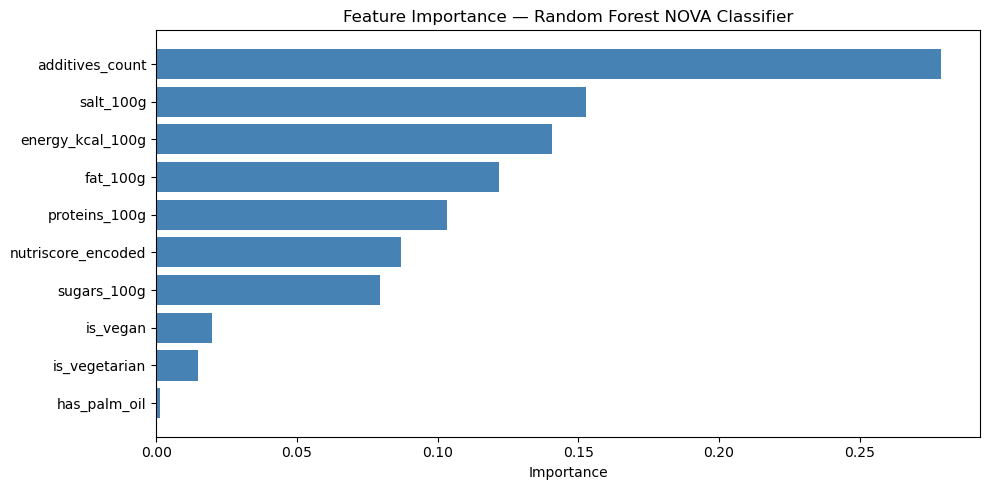

Plot disimpan ke /home/jovyan/work/data/feature_importance.png


In [10]:
import matplotlib.pyplot as plt

# Confusion Matrix
print("=== Confusion Matrix ===")
cm = predictions.groupBy("label", "prediction") \
    .count() \
    .orderBy("label", "prediction")
cm.show()

# Feature Importance
print("=== Feature Importance ===")
importances = rf_model.featureImportances
feat_imp = [(feature_cols[i], float(importances[i])) for i in range(len(feature_cols))]
feat_imp.sort(key=lambda x: x[1], reverse=True)
for feat, imp in feat_imp:
    print(f"  {feat}: {imp:.4f}")

# Visualisasi
features = [f[0] for f in feat_imp]
values = [f[1] for f in feat_imp]

plt.figure(figsize=(10, 5))
plt.barh(features[::-1], values[::-1], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance — Random Forest NOVA Classifier')
plt.tight_layout()
plt.savefig('/home/jovyan/work/data/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan ke /home/jovyan/work/data/feature_importance.png")

## 7. Simpan Model

In [7]:
model_path = "/home/jovyan/work/data/rf_nova_model"
rf_model.save(model_path)
print(f"Model disimpan ke {model_path}")

Model disimpan ke /home/jovyan/work/data/rf_nova_model


## 8. Ringkasan Hasil

In [8]:
print("=" * 50)
print("HASIL MODEL ML — Random Forest NOVA Classifier")
print("=" * 50)
print(f"Training size  : 671.463 baris")
print(f"Test size      : 168.427 baris")
print(f"Jumlah fitur   : {len(feature_cols)}")
print(f"Jumlah trees   : 50")
print(f"Max depth      : 10")
print()
print(f"Accuracy       : 81.58%")
print(f"F1-score macro : 82.13% ✅ (target >= 80%)")
print()
print("F1-score per class:")
print(f"  NOVA 1 (Unprocessed)     : 79.78%")
print(f"  NOVA 2 (Culinary)        : 88.98%")
print(f"  NOVA 3 (Processed)       : 67.30%")
print(f"  NOVA 4 (Ultra-processed) : 87.39%")
print()
print("Top 3 fitur terpenting:")
print(f"  1. additives_count   : 27.88%")
print(f"  2. salt_100g         : 15.27%")
print(f"  3. energy_kcal_100g  : 14.06%")

HASIL MODEL ML — Random Forest NOVA Classifier
Training size  : 671.463 baris
Test size      : 168.427 baris
Jumlah fitur   : 10
Jumlah trees   : 50
Max depth      : 10

Accuracy       : 81.58%
F1-score macro : 82.13% ✅ (target >= 80%)

F1-score per class:
  NOVA 1 (Unprocessed)     : 79.78%
  NOVA 2 (Culinary)        : 88.98%
  NOVA 3 (Processed)       : 67.30%
  NOVA 4 (Ultra-processed) : 87.39%

Top 3 fitur terpenting:
  1. additives_count   : 27.88%
  2. salt_100g         : 15.27%
  3. energy_kcal_100g  : 14.06%
